<a href="https://colab.research.google.com/github/bonnimv/bank-marketing-data/blob/main/notebooks/bank_marketing_part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(90deg, #0f172a, #7c3aed, #db2777); padding: 24px; border-radius: 18px; color: white; box-shadow: 0 8px 24px rgba(0,0,0,0.15);">
  <div>
    <h1 style="margin:0; font-size:30px;">🚀 Lancement du Projet Fil Rouge</h1>
    <p style="margin:8px 0 0 0; font-size:17px; opacity:0.9;">Séance 1 · M1 IA & Business Transformation</p>
    <p style="margin:4px 0 0 0; font-size:14px; opacity:0.75;">Choisissez votre dataset et définissez votre question métier</p>
  </div>
</div>

<div style="background:#f8fafc; border:1px solid #e2e8f0; padding:18px; border-radius:12px; margin-top:14px;">
<b>Le projet fil rouge</b><br>
Tout au long des 4 séances, vous allez construire une <b>analyse data complète</b> sur un dataset de votre choix.<br>
À la fin, vous présenterez vos résultats (notebook + PDF + code) devant le groupe.<br><br>
<b>Ce notebook vous guide pour :</b>
<ol>
  <li>Choisir votre dataset ;</li>
  <li>Définir votre question métier ;</li>
  <li>Faire un premier chargement ;</li>
  <li>Valider votre choix.</li>
</ol>
</div>

<h2 style="color:#7c3aed; border-bottom:2px solid #e9d5ff; padding-bottom:8px; margin-top:30px;">📝 Votre fiche projet</h2>

<div style="border:2px solid #7c3aed; border-left:8px solid #7c3aed; padding:18px; background-color:#faf5ff; border-radius:10px; margin:15px 0;">
<h3 style="color:#7c3aed; margin-top:0;">À compléter</h3>
<ol>
  <li>Choisissez votre dataset en groupe.</li>
  <li>Téléchargez-le depuis Kaggle.</li>
  <li>Complétez la fiche Markdown ci-dessous.</li>
  <li>Exécutez la cellule de chargement et affichez un <code>df.describe()</code>.</li>
</ol>
</div>

### 📋 Fiche Projet — Groupe

Marianna MANENKOVA

---

**Dataset choisi :** *Bank Marketing*

**Lien de téléchargement :** *https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset*

---

**Notre question métier :**
> *Quels sont les facteurs qui influencent le plus la souscription d'un client à un dépôt à terme bancaire lors d'une campagne marketing ?*

**Pourquoi ce dataset nous intéresse :**
> *Ce dataset permet d'analyser l'efficacité des campagnes marketing bancaires et de comprendre le comportement des clients. Les résultats peuvent aider une banque à réduire les coûts des campagnes.*

**Variables que nous pensons importantes :** *age, job, marital, education, balance, housing, loan, contact, duration, campaign, pdays, previous*

**Type de problème anticipé :** *(classification / régression / clustering) classification*

**Ce qu'on espère découvrir :** *Identifier les caractéristiques des clients les plus susceptibles de souscrire à un dépôt à terme afin d'optimiser les futures campagnes marketing de la banque.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print("Bibliothèques chargées ✅")

Bibliothèques chargées ✅


In [2]:
import pandas as pd
from google.colab import files
uploaded = files.upload()  # une fenêtre va s'ouvrir pour choisir ton fichier

# Chargez votre dataset ici
df_raw = pd.read_csv('bank.csv')
df_projet = df_raw.copy()

# Vérifications de base
print("Shape :", df_projet.shape)
print("\nTypes :")
print(df_projet.dtypes)
print("\nAperçu :")
df_projet.head()

Saving bank.csv to bank.csv
Shape : (11162, 17)

Types :
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

Aperçu :


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### 🔍 1.1 — Structure générale

Le dataset contient **11 162 clients** et **17 variables** par client.

On distingue deux types d'informations :
- **Ce qu'on sait du client** : son âge, son métier, sa situation familiale,
  son niveau d'études, s'il a un crédit immobilier ou un prêt personnel,
  son solde bancaire moyen.
- **Ce qui s'est passé lors de la campagne** : combien de fois il a été
  contacté, par quel moyen, combien de temps a duré l'appel.
- **Le résultat** : la colonne `deposit` indique si le client a finalement
  souscrit au dépôt à terme — c'est notre variable cible, celle qu'on
  cherche à expliquer.

In [3]:
# Statistiques descriptives initiales
df_projet.describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00
mean,41.23,1528.54,15.66,371.99,2.51,51.33,0.83
std,11.91,3225.41,8.42,347.13,2.72,108.76,2.29
min,18.00,-6847.00,1.00,2.00,1.00,-1.00,0.00
25%,32.00,122.00,8.00,138.00,1.00,-1.00,0.00
50%,39.00,550.00,15.00,255.00,2.00,-1.00,0.00
75%,49.00,1708.00,22.00,496.00,3.00,20.75,1.00
max,95.00,81204.00,31.00,3881.00,63.00,854.00,58.00


In [4]:
# Valeurs manquantes
missing_nb  = df_projet.isnull().sum()
missing_pct = (df_projet.isnull().mean() * 100).round(1)
missing_df  = pd.DataFrame({'nb_manquants': missing_nb, 'pct (%)': missing_pct})
missing_df  = missing_df[missing_df['nb_manquants'] > 0].sort_values('nb_manquants', ascending=False)

print("=== Valeurs manquantes ===")
if missing_df.empty:
    print("Aucune valeur manquante détectée 🎉")
else:
    print(missing_df)

=== Valeurs manquantes ===
Aucune valeur manquante détectée 🎉


### 🔍 1.2 — Valeurs manquantes

Aucune valeur manquante au sens technique : toutes les cases sont remplies.

Cependant, certaines colonnes contiennent la valeur `"unknown"` (inconnu) à la place d'une vraie information — notamment pour `contact`, `education` et `poutcome`. Ce n'est pas un vrai vide, mais c'est une information absente qu'il faudra traiter lors du nettoyage.

> 💼 En langage métier : tous les dossiers clients sont complets en apparence, mais pour certains clients on ne sait pas par exemple comment ils ont été contactés ou quel était le résultat de la campagne précédente.

In [5]:
# ── 2.1 Doublons et valeurs "unknown" ─────────────────────────────

# Doublons
nb_doublons = df_projet.duplicated().sum()
print(f"Nombre de doublons : {nb_doublons}")
print()

# Valeurs "unknown" par colonne
print("=== Valeurs 'unknown' par colonne ===")
for col in df_projet.select_dtypes(include='object').columns:
    nb_unk = (df_projet[col] == 'unknown').sum()
    pct_unk = (nb_unk / len(df_projet) * 100).round(1)
    if nb_unk > 0:
        print(f"{col:<15} : {nb_unk:>5} ({pct_unk}%)")

Nombre de doublons : 0

=== Valeurs 'unknown' par colonne ===
job             :    70 (0.6%)
education       :   497 (4.5%)
contact         :  2346 (21.0%)
poutcome        :  8326 (74.6%)


### 🧹 2.1 — Doublons et valeurs "unknown"

Aucun doublon détecté : chaque ligne correspond bien à un client unique.

En revanche, plusieurs colonnes contiennent des "unknown" :
- `poutcome` (résultat de la campagne précédente) : 74.6% d'inconnus —
  la majorité des clients n'avaient jamais été contactés avant.
- `contact` (moyen de contact) : 21% d'inconnus.
- `education` : 4.5% et `job` : 0.6%, plus marginaux.

> 💼 En langage métier : les dossiers sont tous uniques, mais la banque
> n'avait pas d'historique sur la plupart des clients contactés pour
> la première fois.

In [6]:
# ── 2.2 Filtrer les outliers et créer df_clean ────────────────────

# Outliers sur campaign (règle 1.5×IQR comme en cours)
q1 = df_projet['campaign'].quantile(0.25)
q3 = df_projet['campaign'].quantile(0.75)
iqr = q3 - q1
borne_sup_campaign = q3 + 1.5 * iqr

print(f"Campaign — Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"Borne supérieure (Q3 + 1.5×IQR) = {borne_sup_campaign}")
print()

# Outliers sur balance
q1_b = df_projet['balance'].quantile(0.25)
q3_b = df_projet['balance'].quantile(0.75)
iqr_b = q3_b - q1_b
borne_sup_balance = q3_b + 1.5 * iqr_b
borne_inf_balance = q1_b - 1.5 * iqr_b

print(f"Balance — borne inf={borne_inf_balance:.0f}€, borne sup={borne_sup_balance:.0f}€")
print()

# Création de df_clean
df_clean = df_projet[
    (df_projet['campaign'] <= borne_sup_campaign) &
    (df_projet['balance'] >= borne_inf_balance) &
    (df_projet['balance'] <= borne_sup_balance)
].copy()

nb_clean = len(df_clean)
pct_clean = round((nb_clean / len(df_projet) * 100), 1)
print(f"Clients conservés dans df_clean : {nb_clean:,}")
print(f"Soit {pct_clean}% du dataset original ({len(df_projet):,} lignes)")

Campaign — Q1=1.0, Q3=3.0, IQR=2.0
Borne supérieure (Q3 + 1.5×IQR) = 6.0

Balance — borne inf=-2257€, borne sup=4087€

Clients conservés dans df_clean : 9,556
Soit 85.6% du dataset original (11,162 lignes)


### 🧹 2.2 — Filtrage des outliers

On applique la règle statistique des 1.5×IQR vue en cours sur deux variables :
- `campaign` : on retire les clients contactés plus de 6 fois —
  au-delà, ce n'est plus du marketing, c'est du harcèlement.
- `balance` : on retire les soldes inférieurs à -2 257€ et
  supérieurs à 4 087€ — des cas trop extrêmes pour être représentatifs.

Après nettoyage, on conserve **9 556 clients (85.6%)** du dataset original.

> 💼 En langage métier : on écarte les cas atypiques pour que nos
> conclusions reflètent le comportement du client "normal" de la banque,
> pas des situations exceptionnelles qui fausseraient l'analyse.

In [7]:
# ── 2.3 Explorer les variables catégorielles ──────────────────────

# Répartition de la variable cible
print("=== Variable cible : deposit ===")
depot_counts = df_clean['deposit'].value_counts()
depot_pct    = df_clean['deposit'].value_counts(normalize=True) * 100
print(pd.DataFrame({'effectif': depot_counts, 'pct (%)': depot_pct.round(1)}))
print()

# Top métiers
print("=== Répartition par métier (job) ===")
print(df_clean['job'].value_counts().head(5))
print()

# Situation familiale
print("=== Situation familiale (marital) ===")
print(df_clean['marital'].value_counts())

=== Variable cible : deposit ===
         effectif  pct (%)
deposit                   
no           5013     52.5
yes          4543     47.5

=== Répartition par métier (job) ===
job
management     2132
blue-collar    1714
technician     1536
admin.         1173
services        813
Name: count, dtype: int64

=== Situation familiale (marital) ===
marital
married     5359
single      3071
divorced    1126
Name: count, dtype: int64


### 🧹 2.3 — Variables catégorielles

**Variable cible `deposit`** : le dataset est quasiment équilibré —
52.5% de clients n'ont pas souscrit (non) contre 47.5% qui ont souscrit (yes).
C'est une très bonne nouvelle : pas besoin de rééquilibrer les classes.

**Métiers** : les cadres (management) sont les plus représentés, suivis
des cols bleus (blue-collar) et des techniciens. La clientèle est donc
très variée socialement.

**Situation familiale** : les mariés sont majoritaires (56%), devant
les célibataires (32%) et les divorcés (12%).

> 💼 En langage métier : on a affaire à une clientèle diverse,
> et les deux groupes (souscripteurs / non-souscripteurs) sont presque
> aussi nombreux l'un que l'autre — ce qui rend notre analyse d'autant
> plus intéressante.

In [8]:
# ── 3.1 Analyse de la balance (solde bancaire) ────────────────────

balance = df_clean['balance']
moyenne    = balance.mean()
mediane    = balance.median()
ecart_type = balance.std()
q1         = balance.quantile(0.25)
q3         = balance.quantile(0.75)
iqr        = q3 - q1
cv         = (ecart_type / moyenne) * 100

print(f"Moyenne    : {moyenne:.1f} €")
print(f"Médiane    : {mediane:.1f} €")
print(f"Écart-type : {ecart_type:.1f} €")
print(f"Q1         : {q1:.1f} €")
print(f"Q3         : {q3:.1f} €")
print(f"IQR        : {iqr:.1f} €")
print(f"CV         : {cv:.1f} %")
print()

print("=== Balance moyenne par réponse (deposit) ===")
stats_deposit = df_clean.groupby('deposit')['balance'].agg(['mean','median','count']).round(1)
print(stats_deposit)

Moyenne    : 817.8 €
Médiane    : 449.5 €
Écart-type : 1001.3 €
Q1         : 99.0 €
Q3         : 1233.2 €
IQR        : 1134.2 €
CV         : 122.4 %

=== Balance moyenne par réponse (deposit) ===
          mean  median  count
deposit                      
no       687.9   347.0   5013
yes      961.1   579.0   4543


### 📊 3.1 — Analyse du solde bancaire (balance)

Moyenne = 817.8€, Médiane = 449.5€, CV = 122.4%

Le CV dépasse largement les 35% vus en cours : les soldes sont très
dispersés, certains clients ont beaucoup d'épargne, d'autres presque rien.
La moyenne (817€) est bien au-dessus de la médiane (449€) : quelques
clients aisés tirent la moyenne vers le haut.

Plus intéressant : les clients qui ont souscrit au dépôt avaient
en moyenne 961€ sur leur compte, contre 688€ pour ceux qui ont refusé.

> 💼 En langage métier : les clients avec plus d'épargne sont davantage
> enclins à placer leur argent dans un dépôt à terme — ce qui est logique,
> on place ce qu'on a.

In [9]:
# ── 3.2 Analyse du taux de souscription par métier ────────────────

taux_job = df_clean.groupby('job')['deposit'].apply(
    lambda x: (x == 'yes').mean() * 100
).round(1).sort_values(ascending=False)

print("=== Taux de souscription par métier (%) ===")
print(taux_job)
print()

print("=== Taux de souscription par niveau d'éducation (%) ===")
taux_education = df_clean.groupby('education')['deposit'].apply(
    lambda x: (x == 'yes').mean() * 100
).round(1).sort_values(ascending=False)
print(taux_education)

=== Taux de souscription par métier (%) ===
job
student          76.3
retired          66.7
unemployed       57.8
unknown          52.7
management       50.2
admin.           47.1
technician       46.9
self-employed    46.4
services         41.0
housemaid        40.3
entrepreneur     36.7
blue-collar      36.7
Name: deposit, dtype: float64

=== Taux de souscription par niveau d'éducation (%) ===
education
tertiary     54.0
unknown      50.0
secondary    45.3
primary      39.5
Name: deposit, dtype: float64


### 📊 3.2 — Taux de souscription par métier et éducation

Par métier, les étudiants (76.3%) et les retraités (66.7%) sont
les plus susceptibles de souscrire. À l'opposé, les cols bleus (36.7%)
et les entrepreneurs (36.7%) sont les moins réceptifs.

Par niveau d'éducation, les clients avec un niveau tertiaire (bac+)
souscrivent davantage (54%) que ceux avec un niveau primaire (39.5%).

> 💼 En langage métier : les étudiants (disponibles et cherchant à épargner)
et les retraités (avec des économies à placer) sont les profils les plus intéressants à cibler. Les ouvriers et entrepreneurs, plus méfiants ou moins disponibles, répondent moins favorablement.

In [10]:
# ── 3.3 Durée d'appel et corrélations ────────────────────────────

print("=== Durée d'appel moyenne par réponse (deposit) ===")
duree = df_clean.groupby('deposit')['duration'].agg(['mean','median']).round(1)
print(duree)
print()

# Corrélation entre variables numériques
num_cols = ['age', 'balance', 'duration', 'campaign', 'previous']
corr = df_clean[num_cols].corr()
print("=== Matrice de corrélation ===")
print(corr.round(2))

=== Durée d'appel moyenne par réponse (deposit) ===
          mean  median
deposit               
no       226.8   167.0
yes      532.8   419.0

=== Matrice de corrélation ===
           age  balance  duration  campaign  previous
age       1.00     0.11     -0.00      0.01      0.03
balance   0.11     1.00      0.02     -0.02      0.06
duration -0.00     0.02      1.00      0.02     -0.03
campaign  0.01    -0.02      0.02      1.00     -0.01
previous  0.03     0.06     -0.03     -0.01      1.00


### 📊 3.3 — Durée d'appel et corrélations

La durée d'appel est le signal le plus fort : les clients qui ont souscrit
ont eu des appels de 533 secondes en moyenne (presque 9 minutes), contre
227 secondes (moins de 4 minutes) pour ceux qui ont refusé — soit plus
du double.

La matrice de corrélation montre que les variables numériques sont
globalement peu corrélées entre elles. Seule la durée d'appel se démarque
comme variable potentiellement explicative.

> 💼 En langage métier : plus un client reste longtemps en ligne avec
> le conseiller, plus il a de chances de souscrire. Cela peut sembler
> évident, mais c'est une confirmation chiffrée très utile : la qualité
> de la conversation téléphonique compte énormément.

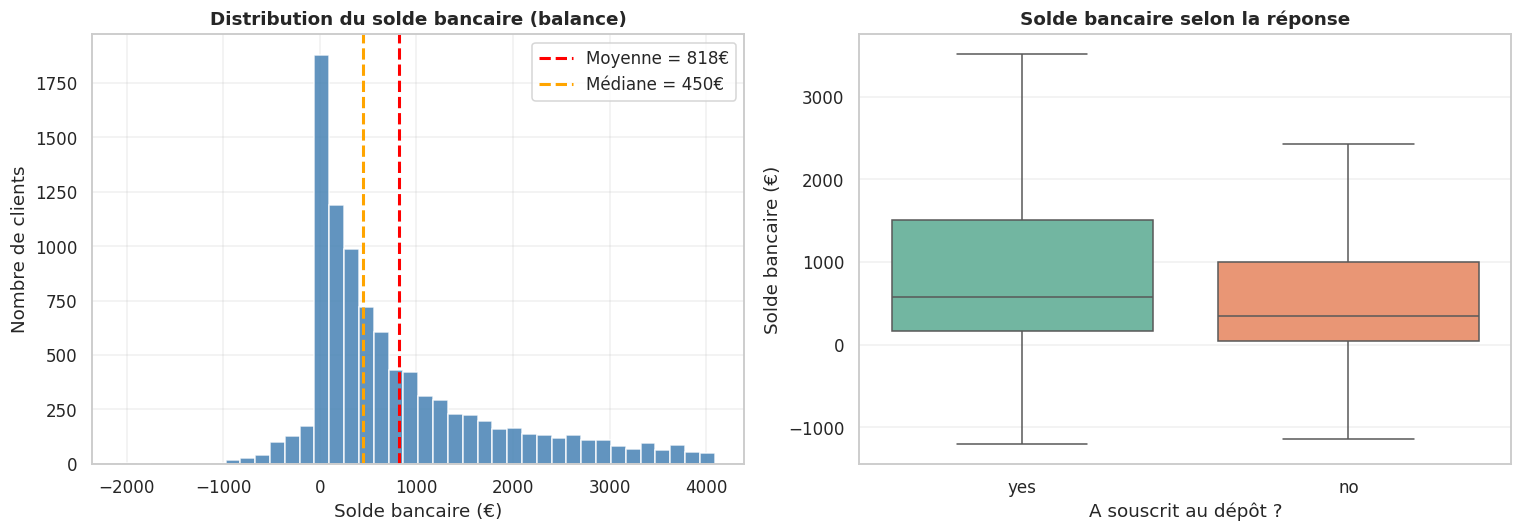

In [11]:
# ── 4.1 Distribution de la balance + boxplot ──────────────────────

mean_b   = df_clean['balance'].mean()
median_b = df_clean['balance'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df_clean['balance'], bins=40, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(mean_b, color='red', linestyle='--', lw=2,
                label=f'Moyenne = {mean_b:.0f}€')
axes[0].axvline(median_b, color='orange', linestyle='--', lw=2,
                label=f'Médiane = {median_b:.0f}€')
axes[0].set_title("Distribution du solde bancaire (balance)", fontweight='bold')
axes[0].set_xlabel("Solde bancaire (€)")
axes[0].set_ylabel("Nombre de clients")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
sns.boxplot(data=df_clean, x='deposit', y='balance', ax=axes[1],
            palette='Set2', showfliers=False)
axes[1].set_title("Solde bancaire selon la réponse", fontweight='bold')
axes[1].set_xlabel("A souscrit au dépôt ?")
axes[1].set_ylabel("Solde bancaire (€)")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 📈 4.1 — Distribution du solde bancaire

L'histogramme confirme ce qu'on avait calculé : la grande majorité des
clients ont un solde modeste (pic autour de 0-500€), mais quelques clients
très aisés tirent la moyenne (818€) bien au-dessus de la médiane (450€).

Le boxplot est encore plus parlant : la boîte des clients qui ont souscrit
(yes) est clairement plus haute que celle des non-souscripteurs (no).
Les clients avec plus d'épargne disent plus souvent oui.

> 💼 En langage métier : la banque a intérêt à cibler en priorité
> les clients avec un solde positif — ce sont eux qui ont de l'argent
> disponible à placer dans un dépôt à terme.

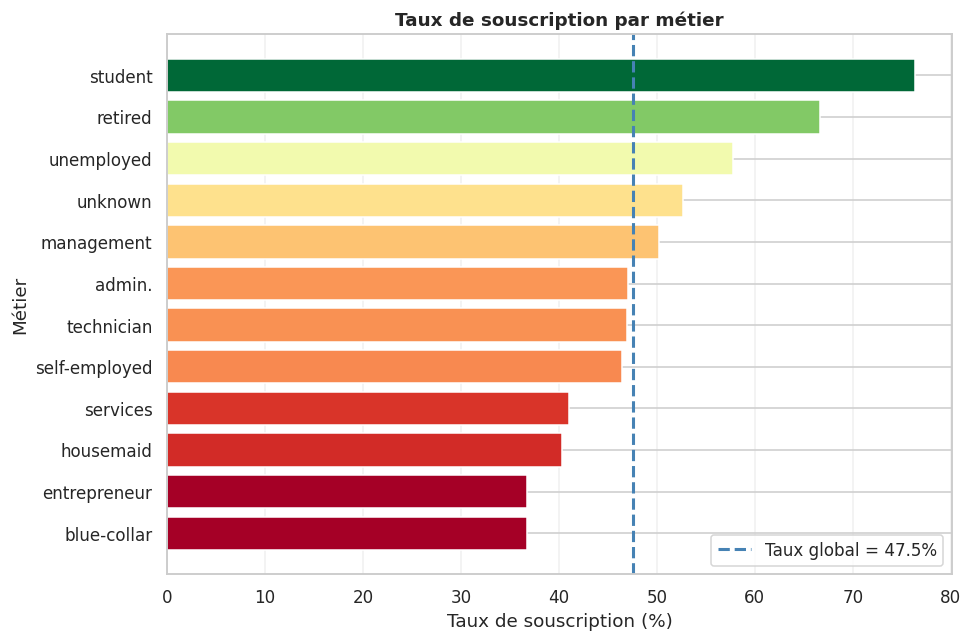

In [12]:
# ── 4.2 Taux de souscription par métier ───────────────────────────

taux_job = df_clean.groupby('job')['deposit'].apply(
    lambda x: (x == 'yes').mean() * 100
).round(1).sort_values()

taux_global = (df_clean['deposit'] == 'yes').mean() * 100
colors = plt.cm.RdYlGn(
    [(v - taux_job.min()) / (taux_job.max() - taux_job.min())
     for v in taux_job]
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(taux_job.index, taux_job.values, color=colors, edgecolor='white')
ax.axvline(taux_global, color='steelblue', linestyle='--', lw=2,
           label=f'Taux global = {taux_global:.1f}%')
ax.set_title("Taux de souscription par métier", fontweight='bold')
ax.set_xlabel("Taux de souscription (%)")
ax.set_ylabel("Métier")
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 📈 4.2 — Taux de souscription par métier

Le graphique est très clair : les étudiants (76%) et les retraités (67%)
sont très au-dessus du taux global (47.5%), tandis que les cols bleus
et les entrepreneurs sont nettement en dessous (37%).

Le dégradé de couleur vert → rouge permet de voir d'un coup d'œil
quels métiers sont les plus et les moins réceptifs.

> 💼 En langage métier : pour optimiser les coûts de la campagne,
> la banque devrait concentrer ses appels sur les étudiants et les
> retraités, et réduire les efforts sur les ouvriers et entrepreneurs
> qui convertissent deux fois moins.

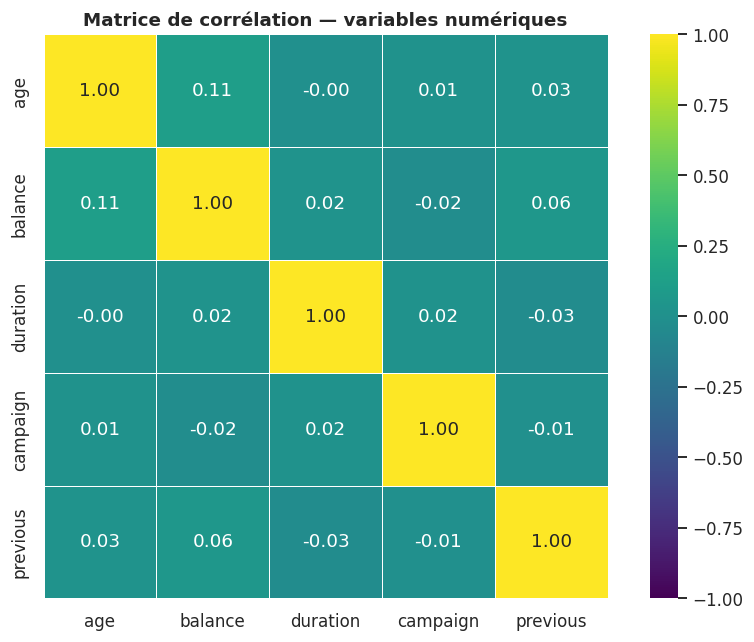

In [13]:
# ── 4.3 Matrice de corrélation ────────────────────────────────────

num_cols = ['age', 'balance', 'duration', 'campaign', 'previous']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matrice de corrélation — variables numériques", fontweight='bold')
plt.tight_layout()
plt.show()

### 📈 4.3 — Matrice de corrélation

La heatmap confirme que les variables numériques sont très peu corrélées
entre elles — presque toutes les cases sont dans des tons sombres (proches
de 0). Aucune paire de variables ne se "copie" l'une l'autre.

C'est une bonne nouvelle pour la suite : chaque variable apporte une
information indépendante, sans redondance.

> 💼 En langage métier : l'âge d'un client, son solde, la durée de
> l'appel et le nombre de contacts sont des informations vraiment
> différentes — elles se complètent plutôt qu'elles se répètent.

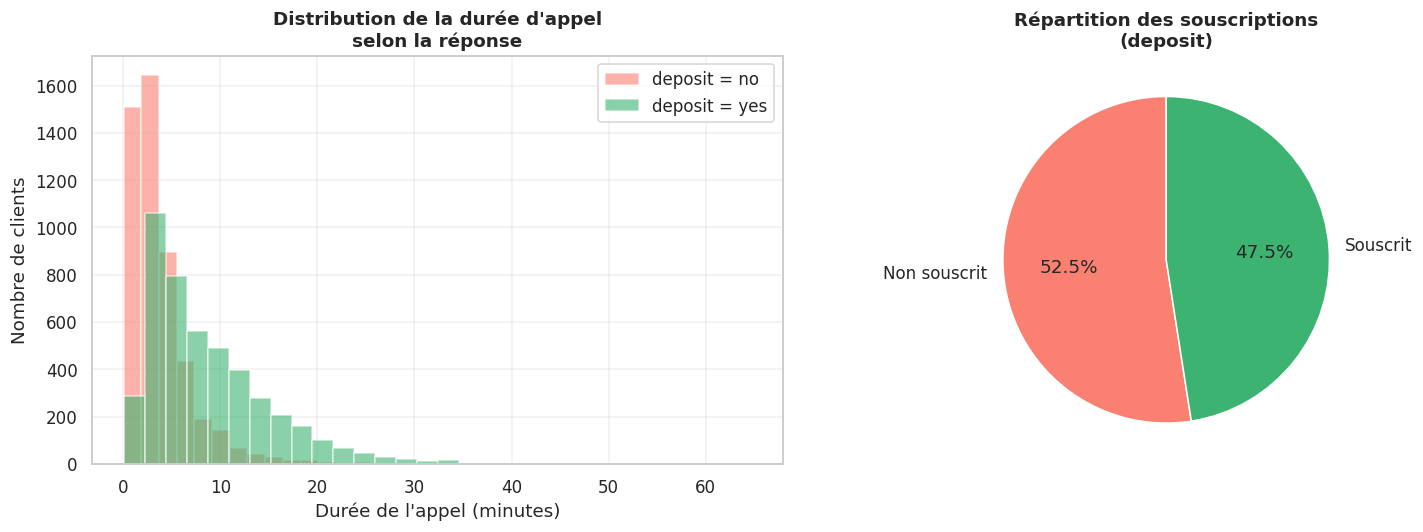

In [14]:
# ── 4.4 Graphique libre : durée d'appel et souscription ───────────
# Question métier : est-ce que la durée de l'appel est vraiment
# le facteur le plus discriminant ?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme de la durée par groupe
for reponse, couleur in zip(['no', 'yes'], ['salmon', 'mediumseagreen']):
    data = df_clean[df_clean['deposit'] == reponse]['duration'] / 60
    axes[0].hist(data, bins=30, alpha=0.6, color=couleur,
                 label=f"deposit = {reponse}", edgecolor='white')

axes[0].set_title("Distribution de la durée d'appel\nselon la réponse",
                  fontweight='bold')
axes[0].set_xlabel("Durée de l'appel (minutes)")
axes[0].set_ylabel("Nombre de clients")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Pie chart de la répartition deposit
depot_counts = df_clean['deposit'].value_counts()
axes[1].pie(depot_counts, labels=['Non souscrit', 'Souscrit'],
            autopct='%1.1f%%', colors=['salmon', 'mediumseagreen'],
            startangle=90)
axes[1].set_title("Répartition des souscriptions\n(deposit)",
                  fontweight='bold')

plt.tight_layout()
plt.show()

### 📈 4.4 — Durée d'appel et répartition des souscriptions

L'histogramme révèle la différence la plus frappante de toute l'analyse :
les clients qui ont souscrit (vert) ont des appels beaucoup plus longs —
leur distribution s'étale vers la droite, jusqu'à plus de 30 minutes.
Les refus (rouge) se concentrent presque tous sur des appels courts
(moins de 5 minutes).

Le pie chart confirme l'équilibre quasi parfait du dataset : 52.5% de
non-souscriptions contre 47.5% de souscriptions.

> 💼 En langage métier : un appel court signifie presque toujours un
> refus. Si le client raccroche vite, il n'est pas intéressé.
> À l'inverse, maintenir la conversation est le signe le plus fiable
> qu'une souscription est en train de se conclure.

In [15]:
# ── 5.1 Dashboard de synthèse ─────────────────────────────────────

total_clients        = len(df_clean)
taux_souscription    = (df_clean['deposit'] == 'yes').mean() * 100
balance_mediane      = df_clean['balance'].median()
metier_top           = (df_clean.groupby('job')['deposit']
                        .apply(lambda x: (x == 'yes').mean() * 100)
                        .idxmax())
duree_moy_yes        = df_clean[df_clean['deposit'] == 'yes']['duration'].mean() / 60
duree_moy_no         = df_clean[df_clean['deposit'] == 'no']['duration'].mean() / 60
pct_unknown_poutcome = (df_clean['poutcome'] == 'unknown').mean() * 100

print("=" * 60)
print("DASHBOARD DE SYNTHÈSE — BANK MARKETING")
print("=" * 60)
print(f"1. Nombre de clients (après nettoyage)     : {total_clients:,}")
print(f"2. Taux de souscription global             : {taux_souscription:.1f}%")
print(f"3. Solde bancaire médian                   : {balance_mediane:.0f}€")
print(f"4. Métier avec le + fort taux              : {metier_top}")
print(f"5. Durée moyenne appel — souscrit          : {duree_moy_yes:.1f} min")
print(f"6. Durée moyenne appel — non souscrit      : {duree_moy_no:.1f} min")
print(f"7. % sans historique campagne précédente   : {pct_unknown_poutcome:.1f}%")
print("=" * 60)

DASHBOARD DE SYNTHÈSE — BANK MARKETING
1. Nombre de clients (après nettoyage)     : 9,556
2. Taux de souscription global             : 47.5%
3. Solde bancaire médian                   : 450€
4. Métier avec le + fort taux              : student
5. Durée moyenne appel — souscrit          : 8.9 min
6. Durée moyenne appel — non souscrit      : 3.8 min
7. % sans historique campagne précédente   : 73.8%


### 📊 5.1 — Dashboard de synthèse

Les 7 chiffres clés de notre analyse sur le dataset Bank Marketing,
après nettoyage des outliers (règle 1.5×IQR).

### 📝 5.2 — Note de synthèse

**Source des données :** dataset Bank Marketing (UCI / Kaggle) —
campagnes de télémarketing d'une banque portugaise. Après nettoyage,
on travaille sur **9 556 clients** et 17 variables.

**Question métier :** quels facteurs influencent la souscription
d'un client à un dépôt à terme bancaire ?

---

**Conclusions sur la souscription :**
Le taux de souscription global est de **47.5%** — le dataset est
quasiment équilibré, ce qui est idéal pour l'analyse.
Le facteur le plus discriminant est la **durée de l'appel** :
les clients qui souscrivent restent en ligne 8.9 minutes en moyenne,
contre seulement 3.8 minutes pour ceux qui refusent — soit plus
du double. Plus la conversation dure, plus la souscription est probable.

**Conclusions sur le profil client :**
Les **étudiants** (76%) et les **retraités** (67%) souscrivent
bien au-dessus du taux global, tandis que les cols bleus et
les entrepreneurs sont les moins réceptifs (37%).
Les clients avec un solde plus élevé (médiane 579€ pour les
souscripteurs vs 347€ pour les non-souscripteurs) sont également
plus enclins à placer leur argent.

**Points de vigilance :**
1. **73.8% des clients n'ont aucun historique** de campagne
   précédente — on ne peut pas s'appuyer sur le passé pour
   la majorité des cas.
2. La durée d'appel est très explicative, mais attention :
   on ne peut pas la contrôler à l'avance — on ne sait pas
   combien de temps durera l'appel avant de l'avoir passé.

**Recommandation :**
Cibler en priorité les étudiants et retraités avec un solde
positif, former les conseillers à prolonger la conversation
de qualité, et construire un modèle de classification pour
prédire dès le départ quels clients sont les plus susceptibles
de souscrire — c'est exactement l'objet des séances suivantes.